# Caderno base: análise de texto

Este caderno usa o exemplo didático dos slides da aula 14: respostas abertas para a pergunta **"O que dificultou sua permanência no curso?"**. O objetivo é praticar um fluxo inicial de NLP: inspecionar respostas, transformar texto em números com TF-IDF, agrupar respostas parecidas e interpretar os grupos com termos fortes e leitura manual.


## Pergunta de análise

Queremos identificar temas recorrentes nas respostas. Como texto livre é ambíguo, os clusters são apenas uma pista: a interpretação final depende de ler exemplos reais de cada grupo.


In [1]:
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Dados de exemplo

As respostas abaixo foram montadas para reproduzir os quatro temas mostrados nos slides: trabalho/turno, laboratório/infraestrutura, transporte/distância e apoio pedagógico.


In [2]:
respostas = [
    "Trabalho a noite e chego cansado para as aulas do curso.",
    "Meu emprego mudou de turno e ficou dificil acompanhar as atividades.",
    "O cansaco depois do trabalho atrapalha estudar e fazer exercicios.",
    "Conciliar trabalho, familia e provas tem sido o maior problema.",
    "O laboratorio fica cheio e nem sempre tem computador disponivel.",
    "A internet do laboratorio cai durante trabalhos e pesquisas.",
    "Falta equipamento para praticar programacao fora do horario de aula.",
    "Computador lento no laboratorio dificulta entregar os trabalhos.",
    "Moro longe do campus e dependo de onibus com poucos horarios.",
    "O transporte atrasa e a distancia ate o campus desanima.",
    "Perco muito tempo no onibus e chego atrasado nas aulas.",
    "A distancia da minha casa ate o campus dificulta a permanencia.",
    "Tenho muitas duvidas em matematica e preciso de monitoria.",
    "Falta apoio para resolver exercicios e revisar conteudos.",
    "Um professor ou monitor poderia tirar duvidas antes das provas.",
    "Preciso de mais apoio pedagogico, monitoria e exemplos resolvidos.",
]

df = pd.DataFrame({
    "id_resposta": range(1, len(respostas) + 1),
    "resposta_aberta": respostas,
})
display(df)


,id_resposta,resposta_aberta
0,1,Trabalho a noite e chego cansado para as aulas...
1,2,Meu emprego mudou de turno e ficou dificil aco...
2,3,O cansaco depois do trabalho atrapalha estudar...
3,4,"Conciliar trabalho, familia e provas tem sido ..."
4,5,O laboratorio fica cheio e nem sempre tem comp...
5,6,A internet do laboratorio cai durante trabalho...
6,7,Falta equipamento para praticar programacao fo...
7,8,Computador lento no laboratorio dificulta entr...
8,9,Moro longe do campus e dependo de onibus com p...
9,10,O transporte atrasa e a distancia ate o campus...


### Leitura inicial

Antes de modelar, vale ler as respostas. Já aparecem palavras que indicam temas: `trabalho`, `laboratorio`, `onibus`, `monitoria`. O algoritmo pode ajudar a organizar esses indícios, mas não substitui a leitura qualitativa.


## Limpeza simples

Para este caderno base, vamos normalizar para minúsculas, remover acentos e trocar pontuação por espaço. Em projetos reais, a limpeza deve preservar informações importantes do domínio; por exemplo, siglas de disciplinas ou nomes de sistemas.


In [3]:
def remover_acentos(texto):
    normalizado = unicodedata.normalize("NFKD", texto)
    return "".join(ch for ch in normalizado if not unicodedata.combining(ch))

def limpar_texto(texto):
    texto = remover_acentos(texto.lower())
    texto = re.sub(r"[^a-z0-9]+", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()

df["texto_limpo"] = df["resposta_aberta"].apply(limpar_texto)
display(df[["resposta_aberta", "texto_limpo"]].head())


,resposta_aberta,texto_limpo
0,Trabalho a noite e chego cansado para as aulas...,trabalho a noite e chego cansado para as aulas...
1,Meu emprego mudou de turno e ficou dificil aco...,meu emprego mudou de turno e ficou dificil aco...
2,O cansaco depois do trabalho atrapalha estudar...,o cansaco depois do trabalho atrapalha estudar...
3,"Conciliar trabalho, familia e provas tem sido ...",conciliar trabalho familia e provas tem sido o...
4,O laboratorio fica cheio e nem sempre tem comp...,o laboratorio fica cheio e nem sempre tem comp...


## Vetorização com TF-IDF

TF-IDF transforma cada resposta em uma linha de matriz. Palavras frequentes em uma resposta, mas não tão comuns no conjunto inteiro, recebem peso maior. Isso ajuda a destacar termos característicos de cada tema.


In [4]:
stopwords_pt = [
    "a", "as", "o", "os", "e", "de", "da", "do", "das", "dos", "para", "por",
    "com", "em", "no", "na", "nos", "nas", "um", "uma", "meu", "minha", "tem",
    "ser", "foi", "fica", "ate", "mais", "muito", "muitas", "sempre",
]

vetor = TfidfVectorizer(stop_words=stopwords_pt, min_df=1, ngram_range=(1, 1))
X = vetor.fit_transform(df["texto_limpo"])
termos = vetor.get_feature_names_out()

print(f"matriz TF-IDF -> {X.shape}")
print("primeiros termos:", ", ".join(termos[:12]))


matriz TF-IDF -> (16, 79)
primeiros termos: acompanhar, antes, apoio, atividades, atrapalha, atrasa, atrasado, aula, aulas, cai, campus, cansaco


### Interpretação da matriz

A matriz tem uma linha por resposta e uma coluna por termo. A maioria dos valores é zero, porque cada resposta usa poucas palavras do vocabulário total. Essa representação numérica é o que permite calcular distância entre respostas.


## Clusterização das respostas

Vamos usar K-Means com 4 clusters para acompanhar o exemplo dos slides. Como o dataset foi construído com quatro temas claros, esperamos grupos relativamente fáceis de interpretar.


In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(X).astype(str)

contagem = df["cluster"].value_counts().sort_index()
display(contagem.rename("respostas_por_cluster").to_frame())

silhueta = silhouette_score(X, df["cluster"])
print(f"Silhueta média: {silhueta:.3f}")


,respostas_por_cluster
cluster,
0,6
1,3
2,3
3,4


Silhueta média: 0.056


### Leitura dos clusters

A contagem mostra se algum grupo ficou vazio ou desbalanceado. A silhueta resume separação média entre grupos: quanto maior, mais nítida tende a ser a separação. Em texto curto, ela é só um sinal auxiliar; a validação principal continua sendo ler respostas por cluster.


## Visualização 2D

A matriz TF-IDF tem muitas dimensões. Para visualizar, usamos `TruncatedSVD` e projetamos cada resposta em dois eixos. A posição 2D é uma aproximação: pontos próximos tendem a compartilhar termos, mas a figura não preserva toda a informação original.


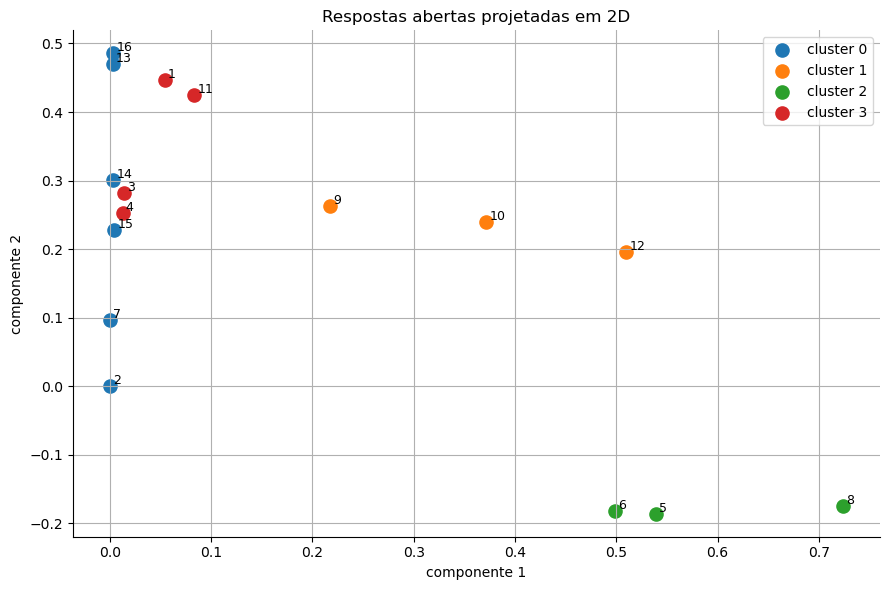

,id_resposta,cluster,x,y,resposta_aberta
1,2,0,0.000123,-0.000387,Meu emprego mudou de turno e ficou dificil aco...
6,7,0,-0.000140,0.096769,Falta equipamento para praticar programacao fo...
12,13,0,0.003072,0.469627,Tenho muitas duvidas em matematica e preciso d...
13,14,0,0.003327,0.300434,Falta apoio para resolver exercicios e revisar...
14,15,0,0.004329,0.228060,Um professor ou monitor poderia tirar duvidas ...
15,16,0,0.003574,0.485594,"Preciso de mais apoio pedagogico, monitoria e ..."
8,9,1,0.217457,0.263126,Moro longe do campus e dependo de onibus com p...
9,10,1,0.371732,0.240019,O transporte atrasa e a distancia ate o campus...
11,12,1,0.509856,0.195913,A distancia da minha casa ate o campus dificul...
4,5,2,0.539566,-0.186206,O laboratorio fica cheio e nem sempre tem comp...


In [6]:
coords = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)
df["x"] = coords[:, 0]
df["y"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, grupo in df.groupby("cluster"):
    ax.scatter(grupo["x"], grupo["y"], s=90, label=f"cluster {cluster_id}")
    for _, linha in grupo.iterrows():
        ax.text(linha["x"] + 0.003, linha["y"] + 0.003, str(linha["id_resposta"]), fontsize=9)
ax.set_title("Respostas abertas projetadas em 2D")
ax.set_xlabel("componente 1")
ax.set_ylabel("componente 2")
ax.legend()
plt.tight_layout()
plt.show()

display(df[["id_resposta", "cluster", "x", "y", "resposta_aberta"]].sort_values(["cluster", "id_resposta"]))


### Interpretação da visualização

Os números no gráfico são os IDs das respostas. Se respostas de um mesmo tema aparecem próximas e com a mesma cor, o agrupamento está coerente. Pontos isolados devem ser lidos manualmente, pois podem misturar temas ou usar vocabulário diferente.


## Termos fortes por cluster

Para nomear um cluster, calculamos a média do TF-IDF das respostas daquele grupo e listamos os termos com maior peso. Esses termos são uma pista para criar nomes interpretáveis.


In [7]:
linhas = []
for cluster_id in sorted(df["cluster"].unique()):
    mascara = (df["cluster"] == cluster_id).to_numpy()
    media_tfidf = np.asarray(X[mascara].mean(axis=0)).ravel()
    top = np.argsort(media_tfidf)[-6:][::-1]
    palavras = [termos[i] for i in top if media_tfidf[i] > 0]
    linhas.append({
        "cluster": cluster_id,
        "termos_fortes": ", ".join(palavras),
        "n_respostas": int(mascara.sum()),
    })

termos_cluster = pd.DataFrame(linhas)
display(termos_cluster)


,cluster,termos_fortes,n_respostas
0,0,"preciso, monitoria, apoio, duvidas, falta, mat...",6
1,1,"campus, distancia, permanencia, casa, transpor...",3
2,2,"laboratorio, computador, trabalhos, nem, dispo...",3
3,3,"trabalho, aulas, chego, curso, noite, cansado",4


### Interpretação dos termos

Os termos fortes devem sugerir nomes como `trabalho e turno`, `infraestrutura de laboratório`, `transporte e distância` e `apoio pedagógico`. A ordem dos números de cluster pode mudar; por isso, sempre nomeie os grupos pelo conteúdo, não pelo ID.


## Exemplos reais por cluster

A etapa final é ler respostas representativas. Aqui vamos listar algumas respostas de cada cluster para confirmar se o nome sugerido pelos termos fortes faz sentido.


In [8]:
for cluster_id in sorted(df["cluster"].unique()):
    print()
    print(f"Cluster {cluster_id}")
    exemplos = df.loc[df["cluster"] == cluster_id, ["id_resposta", "resposta_aberta"]]
    for _, linha in exemplos.iterrows():
        print(f"- #{linha['id_resposta']}: {linha['resposta_aberta']}")



Cluster 0
- #2: Meu emprego mudou de turno e ficou dificil acompanhar as atividades.
- #7: Falta equipamento para praticar programacao fora do horario de aula.
- #13: Tenho muitas duvidas em matematica e preciso de monitoria.
- #14: Falta apoio para resolver exercicios e revisar conteudos.
- #15: Um professor ou monitor poderia tirar duvidas antes das provas.
- #16: Preciso de mais apoio pedagogico, monitoria e exemplos resolvidos.

Cluster 1
- #9: Moro longe do campus e dependo de onibus com poucos horarios.
- #10: O transporte atrasa e a distancia ate o campus desanima.
- #12: A distancia da minha casa ate o campus dificulta a permanencia.

Cluster 2
- #5: O laboratorio fica cheio e nem sempre tem computador disponivel.
- #6: A internet do laboratorio cai durante trabalhos e pesquisas.
- #8: Computador lento no laboratorio dificulta entregar os trabalhos.

Cluster 3
- #1: Trabalho a noite e chego cansado para as aulas do curso.
- #3: O cansaco depois do trabalho atrapalha estudar e 

### Conclusão da análise

Com este conjunto didático, os clusters separam temas recorrentes de permanência estudantil. A conclusão defensável não é apenas "o algoritmo encontrou 4 grupos", mas sim: **as respostas sugerem obstáculos ligados a trabalho, infraestrutura, transporte e apoio pedagógico**. Em um estudo real, o próximo passo seria revisar amostras maiores, permitir múltiplos temas por resposta e comparar os achados com dados estruturados, como turno, curso e frequência.
